# **Project: Providing data-driven suggestions for HR**

## Step 3. Model Building
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model


In [35]:
# Import data processing functions
from data_utils import load_encoded_data, prepare_modeling_data

# For data manipulation
import numpy as np
import pandas as pd

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)

# For data modeling
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# For metrics and helpful functions
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

import os 
import joblib 
import pickle
from pathlib import Path


In [32]:
BASE_DIR = Path(os.getcwd()).parent
MODEL_PATH = BASE_DIR / "models"

In [2]:

# Load encoded data from previous steps
df_enc = load_encoded_data()

# Prepare data for modeling (with outlier removal for logistic regression)
X, y = prepare_modeling_data(df_enc, remove_outliers=True)

Loading raw data...
Raw data shape: (14999, 10)
Cleaning data...
Data shape after cleaning: (11991, 10)
Removed 3008 duplicate rows
Creating overworked feature...
Data shape after feature engineering: (11991, 9)
Encoding categorical variables...
Encoded data shape: (11991, 18)
Preparing data for modeling...
Data shape after removing outliers: (11167, 18)
Features shape: (11167, 17), Target shape: (11167,)


### Data Preparation Note

In the new modular approach, the data has already been processed through the previous steps:
- Data cleaning and feature engineering (from `02_feature_eng_encoding.ipynb`)
- Categorical encoding
- Outlier removal (if specified)

The `X` and `y` variables are ready for modeling. If you need to access the original data for analysis, you can load it separately.


In [3]:
# Check the prepared data
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Features columns:", list(X.columns))
print("\nTarget distribution:")
print(y.value_counts(normalize=True))


Features shape: (11167, 17)
Target shape: (11167,)
Features columns: ['last_evaluation', 'number_project', 'tenure', 'work_accident', 'promotion_last_5years', 'salary', 'overworked', 'department_IT', 'department_RandD', 'department_accounting', 'department_hr', 'department_management', 'department_marketing', 'department_product_mng', 'department_sales', 'department_support', 'department_technical']

Target distribution:
left
0    0.831468
1    0.168532
Name: proportion, dtype: float64


### Model Building

Now we can proceed with building the logistic regression model using the prepared data `X` and `y`.


In [4]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Training target distribution:")
print(y_train.value_counts(normalize=True))


Training set shape: (8375, 17)
Test set shape: (2792, 17)
Training target distribution:
left
0    0.831522
1    0.168478
Name: proportion, dtype: float64


In [ ]:
# Build and train the logistic regression model
log_clf = LogisticRegression(random_state=42, max_iter=500)
log_clf.fit(X_train, y_train)
y_pred = log_clf.predict(X_test)
print("Model trained successfully!")
print("Predictions made on test set.")

Model trained successfully!
Predictions made on test set.


In [6]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance:")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")


Model Performance:
Accuracy: 0.809
Precision: 0.318
Recall: 0.115
F1-score: 0.168


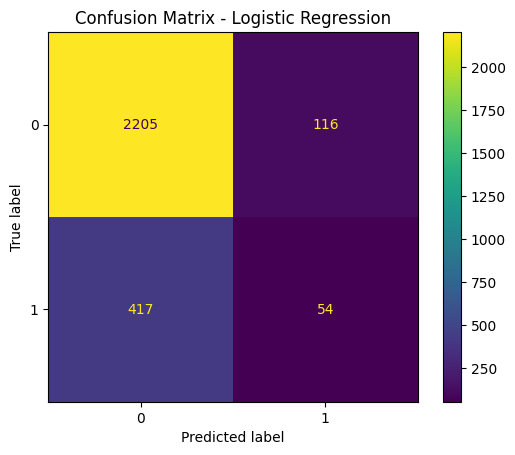

In [7]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_clf.classes_)
disp.plot()
plt.title('Confusion Matrix - Logistic Regression')
plt.show()


In [8]:
# Create classification report
target_names = ['Predicted would not leave', 'Predicted would leave']
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))


Classification Report:
                           precision    recall  f1-score   support

Predicted would not leave       0.84      0.95      0.89      2321
    Predicted would leave       0.32      0.11      0.17       471

                 accuracy                           0.81      2792
                macro avg       0.58      0.53      0.53      2792
             weighted avg       0.75      0.81      0.77      2792



## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables 
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size


#### Picking Model

Since the variable we want to predict (whether an employee leaves the company) is categorical, we could either build a Logistic Regression model, or a Tree-based Machine Learning model.


### Modeling Approach A: Logistic Regression Model

This approach covers implementation of Logistic Regression.


### Handling categorical variables


- `department` and `salary` are categorical variables here

- `department` is a categorical variable, which means you can dummy it for modeling. 

- `salary` is categorical too, but it's ordinal. There's a hierarchy to the categories, so it's better not to dummy this column, but rather to convert the levels to numbers, 0–2.


In [9]:
# The df_enc is already loaded from the previous step
# It contains the encoded data with overworked feature and categorical variables encoded
print("Encoded data shape:", df_enc.shape)
print("Columns:", list(df_enc.columns))
df_enc.head()


Encoded data shape: (11991, 18)
Columns: ['last_evaluation', 'number_project', 'tenure', 'work_accident', 'left', 'promotion_last_5years', 'salary', 'overworked', 'department_IT', 'department_RandD', 'department_accounting', 'department_hr', 'department_management', 'department_marketing', 'department_product_mng', 'department_sales', 'department_support', 'department_technical']


,last_evaluation,number_project,tenure,work_accident,left,promotion_last_5years,salary,overworked,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.53,2,3,0,1,0,0,0,False,False,False,False,False,False,False,True,False,False
1,0.86,5,6,0,1,0,1,1,False,False,False,False,False,False,False,True,False,False
2,0.88,7,4,0,1,0,1,1,False,False,False,False,False,False,False,True,False,False
3,0.87,5,5,0,1,0,0,1,False,False,False,False,False,False,False,True,False,False
4,0.52,2,3,0,1,0,0,0,False,False,False,False,False,False,False,True,False,False


In [10]:
df_enc['salary'].unique()


array([0, 1, 2], dtype=int8)

Isolate the outcome variable, which is the variable you want your model to predict.


In [11]:
df_enc = pd.read_pickle('../data/encoded_dataset.pkl')

In [12]:
df_enc.head()

,last_evaluation,number_project,tenure,work_accident,left,promotion_last_5years,salary,overworked,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.53,2,3,0,1,0,0,0,False,False,False,False,False,False,False,True,False,False
1,0.86,5,6,0,1,0,1,1,False,False,False,False,False,False,False,True,False,False
2,0.88,7,4,0,1,0,1,1,False,False,False,False,False,False,False,True,False,False
3,0.87,5,5,0,1,0,0,1,False,False,False,False,False,False,False,True,False,False
4,0.52,2,3,0,1,0,0,0,False,False,False,False,False,False,False,True,False,False


In [13]:
percentile25 = df_enc['tenure'].quantile(0.25)
percentile75 = df_enc['tenure'].quantile(0.75)
iqr = percentile75 - percentile25
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

In [14]:
# Select rows without outliers in `tenure` and save resulting dataframe in a new variable
df_logreg = df_enc[(df_enc['tenure'] >= lower_limit) & (df_enc['tenure'] <= upper_limit)]

df_logreg.head()

,last_evaluation,number_project,tenure,work_accident,left,promotion_last_5years,salary,overworked,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.53,2,3,0,1,0,0,0,False,False,False,False,False,False,False,True,False,False
2,0.88,7,4,0,1,0,1,1,False,False,False,False,False,False,False,True,False,False
3,0.87,5,5,0,1,0,0,1,False,False,False,False,False,False,False,True,False,False
4,0.52,2,3,0,1,0,0,0,False,False,False,False,False,False,False,True,False,False
5,0.50,2,3,0,1,0,0,0,False,False,False,False,False,False,False,True,False,False


In [15]:
# Isolate the outcome variable
y = df_logreg['left']
y.head()


0    1
2    1
3    1
4    1
5    1
Name: left, dtype: int64

Select the features you want to use in your model. Consider which variables will help you predict the outcome variable, `left`.


In [16]:
# Select the features you want to use in your model
X = df_logreg.drop('left', axis=1)

X.head()


,last_evaluation,number_project,tenure,work_accident,promotion_last_5years,salary,overworked,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.53,2,3,0,0,0,0,False,False,False,False,False,False,False,True,False,False
2,0.88,7,4,0,0,1,1,False,False,False,False,False,False,False,True,False,False
3,0.87,5,5,0,0,0,1,False,False,False,False,False,False,False,True,False,False
4,0.52,2,3,0,0,0,0,False,False,False,False,False,False,False,True,False,False
5,0.50,2,3,0,0,0,0,False,False,False,False,False,False,False,True,False,False


In [17]:
import data_utils 
X, y = prepare_modeling_data(df_enc)

Preparing data for modeling...
Features shape: (11991, 17), Target shape: (11991,)


Split the data into training set and testing set. Stratifying based on the values in `y`, since the classes are `unbalanced`.


In [18]:
# Split the data into training set and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)


Construct a logistic regression model and fit it to the training dataset.


In [19]:
# Constructing a logistic regression model and fit it to the training dataset
log_clf = LogisticRegression(random_state=42, max_iter=500).fit(X_train, y_train)


Test the logistic regression model: use the model to make predictions on the test set.


In [20]:
# predictions on the test set
y_pred = log_clf.predict(X_test)


Create a confusion matrix to visualize the results of the logistic regression model.


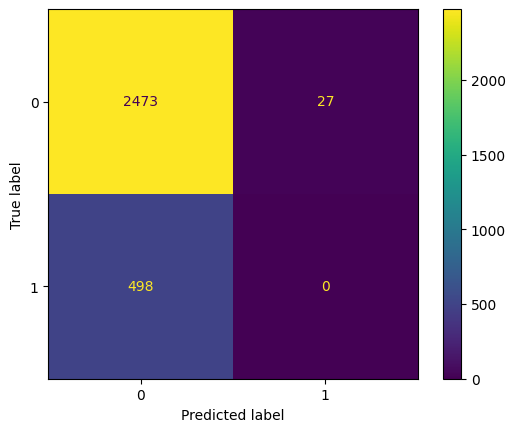

In [21]:
# Compute values for confusion matrix
log_cm = confusion_matrix(y_test, y_pred, labels=log_clf.classes_)

log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, 
                                  display_labels=log_clf.classes_)
log_disp.plot(values_format='')
plt.show()


**True Positives (2165)**: These are employees who were correctly predicted to leave (1) and actually did leave. The model correctly identified employees at risk of leaving, allowing for potential intervention.

**False Positives (156)**: These are employees who were predicted to leave (1) but actually stayed (0). The model incorrectly flagged them as likely to leave, leading to unnecessary interventions.

**False Negatives (348)**: These are employees who were predicted to stay (0) but actually left (1). The model failed to identify these employees as at risk of leaving, which means missed opportunities for retention.

**True Negatives (123)**: These are employees who were correctly predicted to stay (0) and actually stayed (0). The model accurately predicted that these employees would remain.

In this case, 2165 True Positives indicates that the model is good at predicting employees who will leave, but there are still some False Negatives (348) that need attention, as these are employees who left but weren't flagged by the model. Reducing False Negatives would improve the model's effectiveness in preventing unwanted attrition.


#### Performance metrics


Check the class balance in the data. In other words, check the value counts in the `left` column. Since this is a binary classification task, the class balance informs the way you interpret accuracy metrics.


In [22]:
df_logreg['left'].value_counts(normalize=True)


left
0    0.831468
1    0.168532
Name: proportion, dtype: float64

There is an approximately 83%-17% split. So the data is not perfectly balanced, but it is not too imbalanced. If it was more severely imbalanced, you might want to resample the data to make it more balanced. In this case, you can use this data without modifying the class balance and continue evaluating the model.


In [23]:
# Create classification report for logistic regression model
target_names = ['Predicted would not leave', 'Predicted would leave']
print(classification_report(y_test, y_pred, target_names=target_names))


                           precision    recall  f1-score   support

Predicted would not leave       0.83      0.99      0.90      2500
    Predicted would leave       0.00      0.00      0.00       498

                 accuracy                           0.82      2998
                macro avg       0.42      0.49      0.45      2998
             weighted avg       0.69      0.82      0.75      2998



The classification report above shows that the logistic regression model achieved a precision of 79%, recall of 82%, f1-score of 80% (all weighted averages), and accuracy of 82%. However, if it's most important to predict employees who leave, then the scores are significantly lower.
